## 1. Import Libraries

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_swiss_roll
from sklearn.preprocessing import StandardScaler
from torch.utils.data import TensorDataset, DataLoader

# Import FiGuRO from the project
import sys
sys.path.append('../src')
from figuro import FiGuRO

print("Libraries imported successfully!")
print(f"PyTorch version: {torch.__version__}")
print(f"Device: {'cuda' if torch.cuda.is_available() else 'cpu'}")

# set a general random seed for reproducibility
seed = 19
print(f"Using seed: {seed}")
torch.manual_seed(seed)
np.random.seed(seed)
import random
random.seed(seed)

Libraries imported successfully!
PyTorch version: 2.9.1+cu128
Device: cuda
Using seed: 19


## 2. Generate Swiss Roll Dataset

The Swiss Roll is a 3D dataset with intrinsic dimensionality of 2. We'll use this to test FiGuRO's ability to discover the optimal latent dimension.

In [2]:
# Generate Swiss Roll data
n_samples = 5000
X, color = make_swiss_roll(n_samples=n_samples, noise=0.5, random_state=seed)

# Standardize the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Convert to PyTorch tensors
X_tensor = torch.FloatTensor(X_scaled)

# Create train/test split
train_size = int(0.8 * n_samples)
X_train = X_tensor[:train_size]
X_test = X_tensor[train_size:]

# Create DataLoaders
batch_size = 64
train_dataset = TensorDataset(X_train)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

print(f"Dataset shape: {X.shape}")
print(f"Training samples: {len(X_train)}")
print(f"Test samples: {len(X_test)}")
print(f"Feature dimension: {X.shape[1]}")

Dataset shape: (5000, 3)
Training samples: 4000
Test samples: 1000
Feature dimension: 3


### Visualize the Swiss Roll

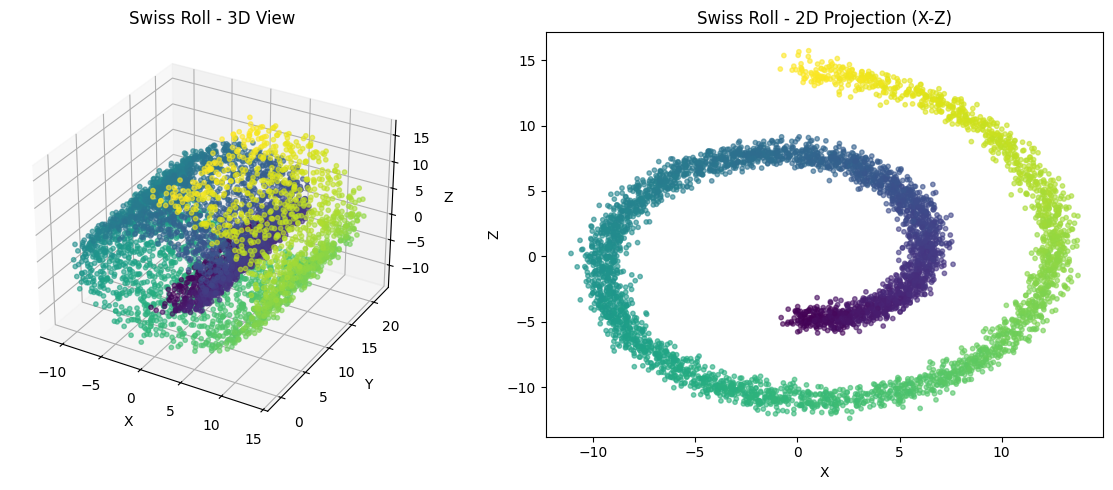

The Swiss Roll has 3 dimensions but intrinsic dimensionality of 2
FiGuRO should discover this and compress accordingly!


In [3]:
fig = plt.figure(figsize=(12, 5))

# 3D view
ax1 = fig.add_subplot(121, projection='3d')
ax1.scatter(X[:, 0], X[:, 1], X[:, 2], c=color, cmap='viridis', s=10, alpha=0.6)
ax1.set_title('Swiss Roll - 3D View')
ax1.set_xlabel('X')
ax1.set_ylabel('Y')
ax1.set_zlabel('Z')

# 2D projection
ax2 = fig.add_subplot(122)
ax2.scatter(X[:, 0], X[:, 2], c=color, cmap='viridis', s=10, alpha=0.6)
ax2.set_title('Swiss Roll - 2D Projection (X-Z)')
ax2.set_xlabel('X')
ax2.set_ylabel('Z')

plt.tight_layout()
plt.show()

print("The Swiss Roll has 3 dimensions but intrinsic dimensionality of 2")
print("FiGuRO should discover this and compress accordingly!")

## 3. Define Simple Autoencoder

We'll create a simple encoder-decoder architecture. FiGuRO will be inserted between them to provide adaptive compression.

In [4]:
class SimpleEncoder(nn.Module):
    """Simple encoder: 3D input -> latent_dim"""
    def __init__(self, input_dim=3, latent_dim=3):
        super(SimpleEncoder, self).__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 16),
            nn.GELU(),
            #nn.Linear(16, 16),
            #nn.GELU(),
            nn.Linear(16, 16),
            nn.GELU(),
            nn.Linear(16, latent_dim),
            nn.Tanh()
        )
    
    def forward(self, x):
        return self.encoder(x)


class SimpleDecoder(nn.Module):
    """Simple decoder: compressed_dim -> 3D output"""
    def __init__(self, compressed_dim, output_dim=3):
        super(SimpleDecoder, self).__init__()
        self.decoder = nn.Sequential(
            nn.Linear(compressed_dim, 16),
            nn.GELU(),
            nn.Linear(16, 16),
            nn.GELU(),
            #nn.Linear(16, 16),
            #nn.GELU(),
            nn.Linear(16, output_dim)
        )
    
    def forward(self, x):
        return self.decoder(x)


# Initialize models
input_dim = 3
latent_dim = 3
compressed_dim = 3  # FiGuRO will compress the latent to this (or less)

encoder = SimpleEncoder(input_dim=input_dim, latent_dim=latent_dim)
decoder = SimpleDecoder(compressed_dim=compressed_dim, output_dim=input_dim)

print(f"Encoder: {input_dim}D -> {latent_dim}D")
print(f"FiGuRO: {latent_dim}D -> {compressed_dim}D (adaptive)")
print(f"Decoder: {compressed_dim}D -> {input_dim}D")
print("\nModel architectures created!")

Encoder: 3D -> 3D
FiGuRO: 3D -> 3D (adaptive)
Decoder: 3D -> 3D

Model architectures created!


## 4. Initialize FiGuRO

FiGuRO will adaptively compress the latent representations. We start with a 3D latent and let FiGuRO discover the optimal compression level.

In [5]:
# Initialize FiGuRO for unimodal compression
figuro = FiGuRO(
    n_modalities=1,              # Single modality (unimodal)
    latent_dims=[latent_dim],    # Input: 3D latent
    decomp_dims=[compressed_dim], # Output: 3D compressed (will adapt down)
    rank_reduction_frequency=10,   # Check rank every 5 epochs
    rank_reduction_threshold=0.01, # SVD energy threshold
    distortion_metric='R2',       # Use R² for quality monitoring
    distortion_threshold=0.1,    # Allow 5% quality drop
    patience=10,                   # Wait 10 checks before adjusting
    initial_rank_ratio=1.0,       # Start at full rank
    min_rank=1,                   # Minimum rank of 1
    use_bias=True
)

print("FiGuRO initialized!")
print(f"Initial rank: {figuro.adaptive_layers[0].active_dims}")
print(f"Max rank: {figuro.adaptive_layers[0].max_rank}")
print(f"Min rank: {figuro.adaptive_layers[0].min_rank}")

FiGuRO initialized!
Initial rank: 3
Max rank: 3
Min rank: 1


## 5. Setup Training

Key points:
1. Add FiGuRO parameters to the optimizer
2. Initialize rank tracking
3. Use standard reconstruction loss

In [6]:
# Training parameters
num_epochs = 2000
learning_rate = 1e-3
warmup_epochs = 100  # Don't reduce rank for first 10 epochs

# Setup optimizer - include FiGuRO parameters!
optimizer = optim.Adam(
    list(encoder.parameters()) + 
    list(decoder.parameters()) + 
    list(figuro.parameters()),
    lr=learning_rate,
    weight_decay=1e-5
)

# Loss function
criterion = nn.MSELoss()

# Initialize FiGuRO tracking
figuro.initialize_tracking(epochs=num_epochs, warmup=warmup_epochs)

print(f"Training setup complete!")
print(f"Epochs: {num_epochs}")
print(f"Warmup: {warmup_epochs}")
print(f"Learning rate: {learning_rate}")
print(f"Rank reduction schedule: {figuro.rank_schedule}")

Training setup complete!
Epochs: 2000
Warmup: 100
Learning rate: 0.001
Rank reduction schedule: [110, 120, 130, 140, 150, 160, 170, 180, 190, 200, 210, 220, 230, 240, 250, 260, 270, 280, 290, 300, 310, 320, 330, 340, 350, 360, 370, 380, 390, 400, 410, 420, 430, 440, 450, 460, 470, 480, 490, 500, 510, 520, 530, 540, 550, 560, 570, 580, 590, 600, 610, 620, 630, 640, 650, 660, 670, 680, 690, 700, 710, 720, 730, 740, 750, 760, 770, 780, 790, 800, 810, 820, 830, 840, 850, 860, 870, 880, 890, 900, 910, 920, 930, 940, 950, 960, 970, 980, 990, 1000, 1010, 1020, 1030, 1040, 1050, 1060, 1070, 1080, 1090, 1100, 1110, 1120, 1130, 1140, 1150, 1160, 1170, 1180, 1190, 1200, 1210, 1220, 1230, 1240, 1250, 1260, 1270, 1280, 1290, 1300, 1310, 1320, 1330, 1340, 1350, 1360, 1370, 1380, 1390, 1400, 1410, 1420, 1430, 1440, 1450, 1460, 1470, 1480, 1490, 1500, 1510, 1520, 1530, 1540, 1550, 1560, 1570, 1580, 1590, 1600, 1610, 1620, 1630, 1640, 1650, 1660, 1670, 1680, 1690, 1700, 1710, 1720, 1730, 1740, 1750, 17

## 6. Training Loop

The training loop:
1. Encode input -> latent
2. Compress latent with FiGuRO -> compressed
3. Decode compressed -> reconstruction
4. Compute loss and backprop
5. Call `figuro.step()` at end of epoch for rank adaptation

In [7]:
# Training history
train_losses = []
rank_history = []
stop_figuro = False
distortion_val = None
original_lr = learning_rate  # Store original learning rate
stop_epoch = None  # Track when FiGuRO stops

import tqdm

print("Starting training...\n")

pbar = tqdm.tqdm(range(num_epochs), desc="Training")

for epoch in pbar:
    encoder.train()
    decoder.train()
    figuro.train()
    
    epoch_loss = 0.0
    epoch_targets = []
    epoch_reconstructed = []
    
    for batch_idx, (data,) in enumerate(train_loader):
        optimizer.zero_grad()
        
        # Forward pass through encoder
        latent = encoder(data)
        
        # Forward pass through FiGuRO (unimodal: single input/output)
        compressed = figuro([latent])[0]  # Returns list, take first element
        
        # Forward pass through decoder
        reconstruction = decoder(compressed[0])
        
        # Compute loss on original data
        loss = criterion(reconstruction, data)
        
        # Backward pass
        loss.backward()
        optimizer.step()
        
        epoch_loss += loss.item()
        
        # Store for FiGuRO step
        with torch.no_grad():
            epoch_targets.append(data.detach())
            epoch_reconstructed.append(reconstruction)
    
    # Average loss
    avg_loss = epoch_loss / len(train_loader)
    train_losses.append(avg_loss)
    
    # Concatenate latents for FiGuRO step
    all_targets = torch.cat(epoch_targets, dim=0)
    all_reconstructed = torch.cat(epoch_reconstructed, dim=0)
    
    # FiGuRO rank adaptation step
    if not stop_figuro:
        figuro.step(epoch, [all_reconstructed], [all_targets])
    
        # Track current rank
        current_rank = figuro.adaptive_layers[0].active_dims
        rank_history.append(current_rank)
        distortion_val = figuro.current_distortion_per_mod
    
    # Print progress
    #if (epoch + 1) % 10 == 0 or epoch < 15:
    #    print(f"Epoch [{epoch+1}/{num_epochs}] - Loss: {avg_loss:.6f} - Rank: {current_rank} - Distortion: {distortion_val}")

    # early stopping
    #if (epoch > warmup_epochs) and (figuro.patience_counter > figuro.patience**2):
    #    print(f"Early stopping at epoch {epoch+1} due to no improvement in distortion.")
    #    break

    # Check if FiGuRO should stop and set up linear LR schedule
    if (not stop_figuro) and (figuro.adaptive_layers[0].min_rank == figuro.adaptive_layers[0].max_rank) and (figuro.patience_counter >= figuro.patience):
        stop_figuro = True
        stop_epoch = epoch
        print(f"\nMin and max rank have converged at epoch {epoch+1}. Stopping rank optimization.")
        print(f"Setting up linear LR schedule from {10*original_lr:.2e} to {0.1*original_lr:.2e}")
    
    # Apply linear learning rate schedule after FiGuRO stops
    if stop_figuro and stop_epoch is not None:
        remaining_epochs = num_epochs - stop_epoch
        progress = (epoch - stop_epoch) / remaining_epochs
        # Linear interpolation: 10x -> 0.1x
        lr_multiplier = 10.0 - (10.0 - 0.1) * progress
        new_lr = original_lr * lr_multiplier
        for param_group in optimizer.param_groups:
            param_group['lr'] = new_lr
    
    # Update progress bar with current metrics
    current_lr = optimizer.param_groups[0]['lr']
    pbar.set_postfix({
        'Loss': f'{avg_loss:.6f}',
        'Rank': current_rank if not stop_figuro else rank_history[-1],
        'R²': distortion_val,
        'LR': f'{current_lr:.2e}'
    })

print("\nTraining complete!")


Starting training...



Training:   6%|▌         | 111/2000 [00:25<06:32,  4.81it/s, Loss=0.012901, Rank=3, R²=[0.9872737526893616], LR=1.00e-03]

Starting rank reduction at epoch 110
Initial distortion metrics: [0.9872737526893616], thresholds set to: [0.8872737526893616]


Training:   6%|▌         | 121/2000 [00:27<07:47,  4.02it/s, Loss=0.009643, Rank=2, R²=[0.9903910756111145], LR=1.00e-03]

Updated distortion metric maxima to: [0.9903910756111145], thresholds to: [0.8903910756111145]


...

Adjusting minimum ranks to [2]


Training:  22%|██▏       | 441/2000 [01:40<05:40,  4.59it/s, Loss=0.054996, Rank=2, R²=[0.9449829459190369], LR=1.00e-02]


Min and max rank have converged at epoch 441. Stopping rank optimization.
Setting up linear LR schedule from 1.00e-02 to 1.00e-04


Training: 100%|██████████| 2000/2000 [07:42<00:00,  4.33it/s, Loss=0.001871, Rank=2, R²=[0.9449829459190369], LR=1.06e-04]


Training complete!


## 7. Visualize Training Results

Let's see how the loss and rank evolved during training.

Figure saved to: ../03_results/plots/swiss_roll_analysis.png


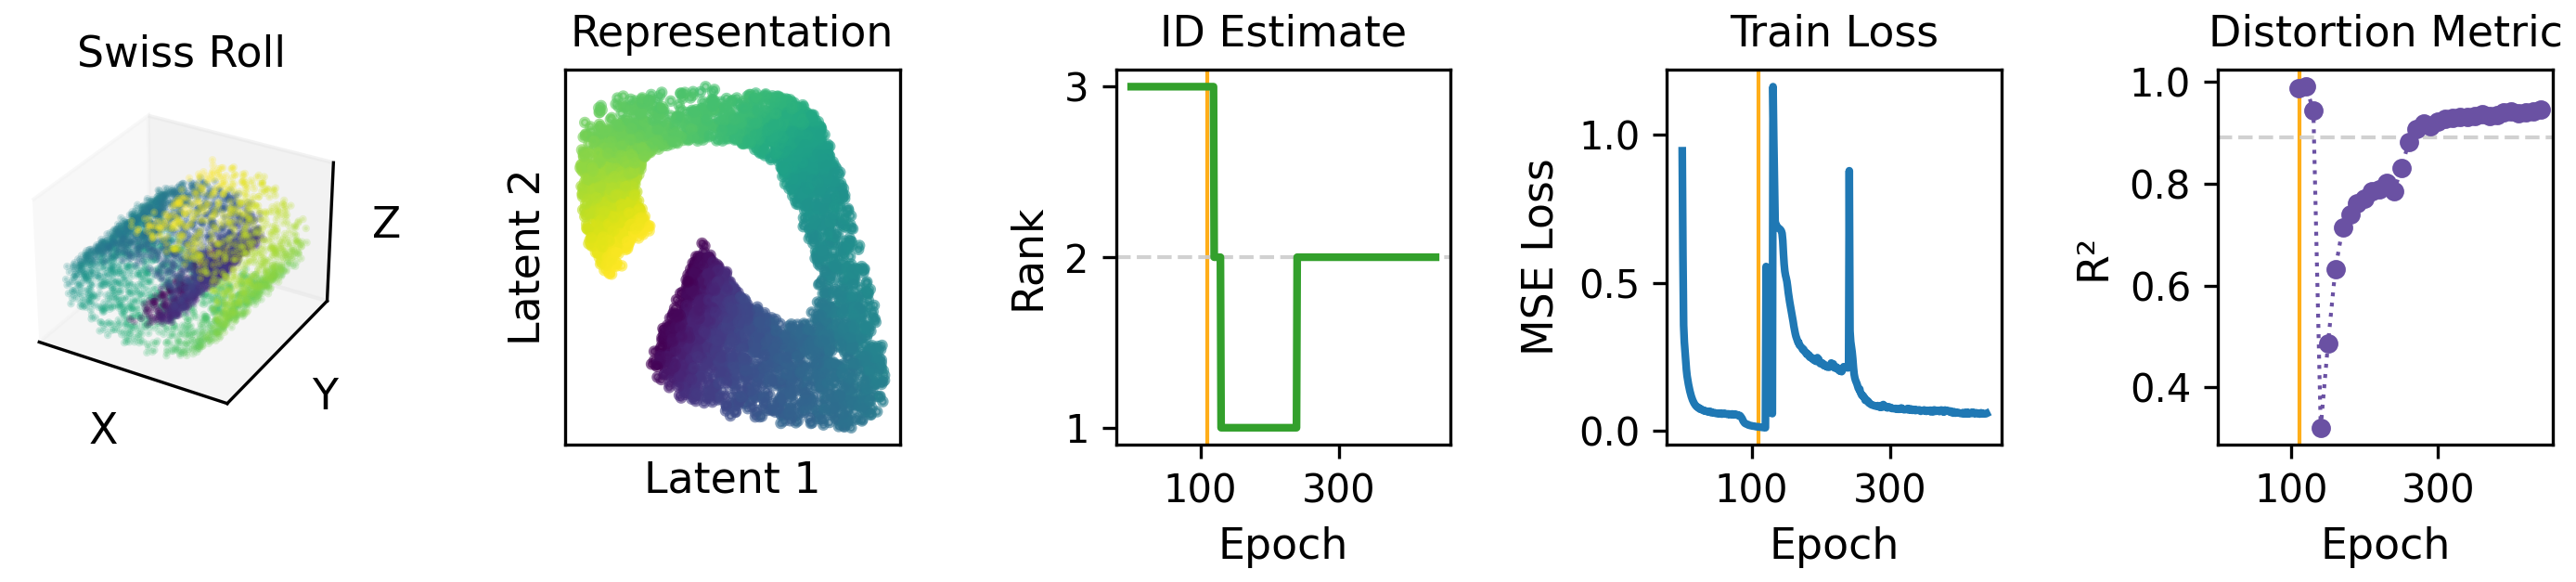


Figure Summary:
  Final Rank: 2
  True Intrinsic Dimension: 2
  Final Loss: 0.057880


In [30]:
# Create a publication-ready figure (1 row x 5 columns)
# Following the same style as the paper's sphere figure

# Configure matplotlib for paper style
plt.rcParams.update({
    'font.size': 11,
    'axes.titlesize': 11,
    'axes.labelsize': 11,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'figure.titlesize': 12,
    'font.family': 'sans-serif',
    'mathtext.fontset': 'stix',
    'figure.dpi': 300,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'savefig.pad_inches': 0.05,
    'axes.linewidth': 0.8,
    'grid.linewidth': 0.5
})

vline_color = 'orange'
vline_x = 110

# Create figure
fig = plt.figure(figsize=(9.45, 2.32))

# Get compressed representations for visualization
encoder.eval()
figuro.eval()
decoder.eval()

with torch.no_grad():
    train_latent = encoder(X_train)
    train_compressed = figuro.encode([train_latent])[0]
    
# Convert to numpy
train_compressed_np = train_compressed.cpu().numpy()

# Perform PCA for 2D visualization
from sklearn.decomposition import PCA
#pca = PCA(n_components=2)
#latent_2d = pca.fit_transform(train_compressed_np)
latent_2d = train_compressed_np[:, :2]  # Take first two dimensions directly

# Column 1: Original Swiss Roll in 3D
ax1 = fig.add_subplot(1, 5, 1, projection='3d')
ax1.scatter(X[:train_size, 0], X[:train_size, 1], X[:train_size, 2], 
           c=color[:train_size], cmap='viridis', s=1, alpha=0.2)
ax1.set_title('Swiss Roll')
ax1.set_xticks([])
ax1.set_yticks([])
ax1.set_zticks([])
ax1.set_xlabel('X', fontsize=11, labelpad=-10)
ax1.set_ylabel('Y', fontsize=11, labelpad=-10)
ax1.set_zlabel('Z', fontsize=11, labelpad=-12)

# Column 2: Learned Representation (2D PCA projection)
ax2 = fig.add_subplot(1, 5, 2)
ax2.scatter(latent_2d[:, 0], latent_2d[:, 1], 
           c=color[:train_size], cmap='viridis', s=4, alpha=0.6)
ax2.set_title('Representation')
ax2.set_xlabel('Latent 1')
ax2.set_ylabel('Latent 2')
# remove axis ticks
ax2.set_xticks([])
ax2.set_yticks([])

# Column 3: Rank Evolution
ax3 = fig.add_subplot(1, 5, 3)
epochs_r = np.arange(len(rank_history))
ax3.axvline(x=vline_x, color=vline_color, linestyle='-', linewidth=1, alpha=0.9)
ax3.axhline(y=2, color='#cccccc', linestyle='--', linewidth=1, alpha=0.9)
ax3.plot(epochs_r, rank_history, color='#33a02c', linewidth=2)
ax3.set_title('ID Estimate')
ax3.set_xlabel('Epoch')
ax3.set_ylabel('Rank')

# Column 4: Training Loss
ax4 = fig.add_subplot(1, 5, 4)
#epochs_loss = np.arange(len(train_losses))
# limit them to [0, stop_epoch]
train_losses = train_losses[:stop_epoch]
epochs_loss = np.arange(len(train_losses))
ax4.axvline(x=vline_x, color=vline_color, linestyle='-', linewidth=1, alpha=0.9)
ax4.plot(epochs_loss, train_losses, color='#1f78b4', linewidth=2)
ax4.set_title('Train Loss')
ax4.set_xlabel('Epoch')
ax4.set_ylabel('MSE Loss')

# Column 5: R² Distortion Metric
ax5 = fig.add_subplot(1, 5, 5)
if len(figuro.distortion_metric_values) > 0:
    distortions = figuro.distortion_metric_values
    distortion_epochs = figuro.rank_schedule[:len(distortions)]
    # add (distortion_epochs[0] / rank_reduction_frequency) many nans
    distortions_filled = [None] * int(figuro.rank_schedule[0] / figuro.rank_reduction_frequency) + [d[0] for d in distortions]
    distortion_epochs_filled = [int(e) for e in np.linspace(0, figuro.rank_schedule[0], int(figuro.rank_schedule[0] / figuro.rank_reduction_frequency))] + distortion_epochs
    ax5.axvline(x=vline_x+int(figuro.rank_schedule[0] / figuro.rank_reduction_frequency)-10, color=vline_color, linestyle='-', linewidth=1, alpha=0.9)
    # Threshold line
    first_r2 = max(distortions)[0]
    threshold_line = first_r2 - 0.1
    ax5.axhline(y=threshold_line, color='#cccccc', linestyle='--', linewidth=1, alpha=0.9)
    #ax5.plot(distortion_epochs, distortions, color='#6a51a3', 
    #        linestyle=':', marker='o', linewidth=1, markersize=4)
    ax5.plot(distortion_epochs_filled, distortions_filled, color='#6a51a3', linestyle=':', marker='o', linewidth=1, markersize=4)
    ax5.set_title('Distortion Metric')
    ax5.set_xlabel('Epoch')
    ax5.set_ylabel('R²')
    ax5.set_xlim(0)
else:
    ax5.text(0.5, 0.5, 'No R² data\n(tracking starts\nafter warmup)', 
            ha='center', va='center', fontsize=9)
    ax5.set_title('Distortion Metric')

# Align epoch ticks across rank, loss, and R² plots
max_epoch = max(len(rank_history), len(train_losses))
desired_ticks = [100, 300]
tick_positions = [int(t) for t in desired_ticks if t <= max_epoch - 1]
if not tick_positions:
    tick_positions = [0, max_epoch - 1]

for ax in (ax3, ax4, ax5):
    ax.set_xticks(tick_positions)
#    ax.set_xticklabels([str(int(t)) for t in tick_positions])

plt.tight_layout()
plt.savefig(f'../03_results/plots/swiss_roll_analysis_seed{seed}.png', dpi=300, bbox_inches='tight')
print(f"Figure saved to: ../03_results/plots/swiss_roll_analysis.png")
plt.show()

print(f"\nFigure Summary:")
print(f"  Final Rank: {rank_history[-1]}")
print(f"  True Intrinsic Dimension: 2")
print(f"  Final Loss: {train_losses[-1]:.6f}")
#print(f"  PCA Explained Variance: {pca.explained_variance_ratio_.sum():.4f}")